In [1]:
import pandas as pd
df=pd.read_csv(r"C:\Users\vshya\OneDrive\Desktop\Projects\Loan\Loan_default.csv")
df

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
255342,8C6S86ESGC,19,37979,210682,541,109,4,14.11,12,0.85,Bachelor's,Full-time,Married,No,No,Other,No,0
255343,98R4KDHNND,32,51953,189899,511,14,2,11.55,24,0.21,High School,Part-time,Divorced,No,No,Home,No,1
255344,XQK1UUUNGP,56,84820,208294,597,70,3,5.29,60,0.50,High School,Self-employed,Married,Yes,Yes,Auto,Yes,0
255345,JAO28CPL4H,42,85109,60575,809,40,1,20.90,48,0.44,High School,Part-time,Single,Yes,Yes,Other,No,0


In [2]:
print(df.duplicated().sum())

0


In [3]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler

df = pd.read_csv("Loan_default.csv")

loan_ids = df["LoanID"]

y = df["Default"]

X = df.drop(columns=["LoanID", "Default"])

df_encoded = X.copy()
categorical_cols = df_encoded.select_dtypes(include='object').columns

label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    label_encoders[col] = le

numerical_cols = df_encoded.select_dtypes(include=["int64", "float64"]).columns
scaler = StandardScaler()
df_encoded[numerical_cols] = scaler.fit_transform(df_encoded[numerical_cols])

X_processed = df_encoded
y_processed = y.reset_index(drop=True)

print(f"X_processed shape: {X_processed.shape}")
print(X_processed.head())


X_processed shape: (255347, 16)
        Age    Income  LoanAmount  CreditScore  MonthsEmployed  \
0  0.833990  0.089693   -1.086833    -0.341492        0.590533   
1  1.701221 -0.823021   -0.044309    -0.731666       -1.285731   
2  0.166888  0.043854    0.022715    -0.775718       -0.968209   
3 -0.767053 -1.303452   -1.168538     1.061875       -1.718715   
4  1.100830 -1.592855   -1.671921     0.369631       -1.487790   

   NumCreditLines  InterestRate  LoanTerm  DTIRatio  Education  \
0        1.341937      0.261771 -0.001526 -0.260753          0   
1       -1.343791     -1.308350  1.412793  0.778585          2   
2        0.446694      1.156831 -0.708685 -0.823728          2   
3        0.446694     -0.967805 -0.708685 -1.170174          1   
4        1.341937     -1.052188  0.705634  0.995114          0   

   EmploymentType  MaritalStatus  HasMortgage  HasDependents  LoanPurpose  \
0               0              0            1              1            4   
1               0   

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y_processed,
    test_size=0.2,          
    random_state=42,        
    stratify=y_processed    
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train distribution:\n{y_train.value_counts(normalize=True)}")
print(f"y_test distribution:\n{y_test.value_counts(normalize=True)}")

X_train shape: (204277, 16)
X_test shape: (51070, 16)
y_train distribution:
Default
0    0.883873
1    0.116127
Name: proportion, dtype: float64
y_test distribution:
Default
0    0.883865
1    0.116135
Name: proportion, dtype: float64


In [5]:
from imblearn.combine import SMOTETomek

smote_tomek = SMOTETomek(random_state=42)

X_train_bal, y_train_bal = smote_tomek.fit_resample(X_train, y_train)

print("After SMOTE-Tomek:")
print(y_train_bal.value_counts(normalize=True))


After SMOTE-Tomek:
Default
0    0.5
1    0.5
Name: proportion, dtype: float64


In [6]:
# Random Forest for Loan Default Prediction

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# Split
x_train, x_test, y_train, y_test = train_test_split(X_processed, y_processed, test_size=0.3, random_state=42, stratify=y_processed)

# Train Random Forest
RandomForestModel = RandomForestClassifier(random_state=42)
RandomForestModel.fit(x_train, y_train)

# Predict
predictions = RandomForestModel.predict(x_test)
print(predictions)

from sklearn.metrics import classification_report, accuracy_score

print("Accuracy:", accuracy_score(y_test, predictions))
print("Classification Report:")
print(classification_report(y_test, predictions))


[0 0 0 ... 0 0 0]
Accuracy: 0.8854252333398603
Classification Report:
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     67709
           1       0.59      0.04      0.08      8896

    accuracy                           0.89     76605
   macro avg       0.74      0.52      0.51     76605
weighted avg       0.85      0.89      0.84     76605



In [7]:
# Decision Tree Classifier for Loan Default Prediction

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

x_train, x_test, y_train, y_test = train_test_split(
    X_processed, y_processed, test_size=0.3, random_state=42, stratify=y_processed
)

# 3. Train Decision Tree model
classifier = DecisionTreeClassifier(random_state=42)
classifier.fit(x_train, y_train)

# 4. Make predictions
y_pred = classifier.predict(x_test)

# 5. Show predictions and performance
print("Predictions:\n", y_pred)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Predictions:
 [0 0 0 ... 0 1 0]
Accuracy: 0.8044775145225508
Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.88      0.89     67709
           1       0.21      0.24      0.22      8896

    accuracy                           0.80     76605
   macro avg       0.55      0.56      0.55     76605
weighted avg       0.82      0.80      0.81     76605



In [8]:
#knn
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
# 2. Split into train/test sets
x_train, x_test, y_train, y_test = train_test_split(
    X_processed, y_processed, test_size=0.3, random_state=42, stratify=y_processed
)

# 3. Train KNN classifier
knn = KNeighborsClassifier(n_neighbors=5)  # You can tune this 'k' later
knn.fit(x_train, y_train)

# 4. Predict on test set
y_pred = knn.predict(x_test)

# 5. Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.8741727041315841
Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.98      0.93     67709
           1       0.32      0.07      0.12      8896

    accuracy                           0.87     76605
   macro avg       0.60      0.53      0.53     76605
weighted avg       0.82      0.87      0.84     76605



In [9]:
#xg boost
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
x_train, x_test, y_train, y_test = train_test_split(
    X_processed, y_processed, test_size=0.3, random_state=42, stratify=y_processed
)

# 5. Train XGBoost classifier
xgb = XGBClassifier(eval_metric='logloss', random_state=42)
xgb.fit(x_train, y_train)

# 6. Predict
y_pred = xgb.predict(x_test)

# 7. Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.885359963448861
Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.99      0.94     67709
           1       0.54      0.09      0.15      8896

    accuracy                           0.89     76605
   macro avg       0.72      0.54      0.54     76605
weighted avg       0.85      0.89      0.85     76605



In [14]:
!pip install pandas numpy scikit-learn xgboost imblearn joblib streamlit

  Obtaining dependency information for imblearn from https://files.pythonhosted.org/packages/81/a7/4179e6ebfd654bd0eac0b9c06125b8b4c96a9d0a8ff9e9507eb2a26d2d7e/imblearn-0.0-py2.py3-none-any.whl.metadata
  Obtaining dependency information for streamlit from https://files.pythonhosted.org/packages/62/b1/44bd5f0eb1a6d9fa045db1e8bca77dc6751c12f7dacebf820ee708ea5acc/streamlit-1.47.0-py3-none-any.whl.metadata
  Obtaining dependency information for altair<6,>=4.0 from https://files.pythonhosted.org/packages/aa/f3/0b6ced594e51cc95d8c1fc1640d3623770d01e4969d29c0bd09945fafefa/altair-5.5.0-py3-none-any.whl.metadata
  Obtaining dependency information for blinker<2,>=1.5.0 from https://files.pythonhosted.org/packages/10/cb/f2ad4230dc2eb1a74edf38f1a38b9b52277f75bef262d8908e60d957e13c/blinker-1.9.0-py3-none-any.whl.metadata
  Obtaining dependency information for cachetools<7,>=4.0 from https://files.pythonhosted.org/packages/00/f0/2ef431fe4141f5e334759d73e81120492b23b2824336883a91ac04ba710b/cachetool

In [60]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from imblearn.over_sampling import SMOTE
import joblib # Used for saving/loading Python objects

print("--- Starting Model Preparation ---")

# --- 1. Load Data ---
print("Loading data...")
df = pd.read_csv("Loan_default.csv")

# --- 2. Separate Features (X) and Target (y) ---
X = df.drop(['LoanID', 'Default'], axis=1)
y = df['Default']
print(f"Original data shape: {df.shape}")

# --- 3. Preprocessing: Label Encoding for Categorical Features ---
print("Applying Label Encoding to categorical features...")
label_encoders = {}
categorical_cols = X.select_dtypes(include=['object']).columns

for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le # Store the fitted encoder

print(f"Categorical columns encoded: {list(categorical_cols)}")

# --- 4. Train/Test Split BEFORE Resampling ---
print("Splitting data into training and testing sets (80/20)...")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# --- 5. Handle Class Imbalance using SMOTE on Training Data ONLY ---
print("Applying SMOTE to balance the training data...")
sm = SMOTE(random_state=42)
X_train_bal, y_train_bal = sm.fit_resample(X_train, y_train)
print(f"X_train_balanced shape: {X_train_bal.shape}")

# --- 6. Feature Scaling (Standardization) ---
print("Applying StandardScaler to numerical features...")
scaler = StandardScaler()
numerical_features = X.select_dtypes(include=np.number).columns
X_train_bal[numerical_features] = scaler.fit_transform(X_train_bal[numerical_features])
# Transform the test set using the *fitted* scaler from the training data
X_test[numerical_features] = scaler.transform(X_test[numerical_features])
print("Features scaled.")

# --- 7. Train XGBoost Classifier ---
print("Training XGBoost Classifier (this might take a while)...")
xgb_model = xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train_bal, y_train_bal)
print("XGBoost model trained.")

# --- 8. Save the Trained Model, Scaler, and Label Encoders ---
print("Saving model, scaler, and label encoders...")
joblib.dump(xgb_model, 'xgboost_loan_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(label_encoders, 'label_encoders.pkl')
print("All necessary files saved successfully: 'xgboost_loan_model.pkl', 'scaler.pkl', 'label_encoders.pkl'")

print("\n--- Model Preparation Complete ---")
print("You can now proceed to the next cell to create and run the Streamlit app.")

--- Starting Model Preparation ---
Loading data...
Original data shape: (255347, 18)
Applying Label Encoding to categorical features...
Categorical columns encoded: ['Education', 'EmploymentType', 'MaritalStatus', 'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner']
Splitting data into training and testing sets (80/20)...
Applying SMOTE to balance the training data...
X_train_balanced shape: (361110, 16)
Applying StandardScaler to numerical features...
Features scaled.
Training XGBoost Classifier (this might take a while)...


C:\Users\vshya\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [12:14:06] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost model trained.
Saving model, scaler, and label encoders...
All necessary files saved successfully: 'xgboost_loan_model.pkl', 'scaler.pkl', 'label_encoders.pkl'

--- Model Preparation Complete ---
You can now proceed to the next cell to create and run the Streamlit app.


In [20]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import joblib # Used for loading saved Python objects

# --- 1. Load Pre-trained Model and Preprocessors ---
try:
    model = joblib.load('xgboost_loan_model.pkl')
    scaler = joblib.load('scaler.pkl')
    label_encoders = joblib.load('label_encoders.pkl')
    st.sidebar.success("Model and preprocessors loaded successfully!")
except FileNotFoundError:
    st.error("Error: Model or preprocessor files not found. Please ensure 'xgboost_loan_model.pkl', 'scaler.pkl', and 'label_encoders.pkl' are in the same directory as app.py, and that you've run the model preparation code first.")
    st.stop()

# --- 2. Define Feature Names and Their Types ---
# This list MUST be in the same order as the features were during model training.
# This is CRUCIAL for ensuring consistent input for both scaler and model.
feature_names = [
    'Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed',
    'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio',
    'Education', 'EmploymentType', 'MaritalStatus', 'HasMortgage',
    'HasDependents', 'LoanPurpose', 'HasCoSigner'
]

numerical_features = [
    'Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed',
    'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio'
]

categorical_features_options = {
    'Education': ['High School', 'Bachelor\'s', 'Master\'s', 'PhD'],
    'EmploymentType': ['Full-time', 'Part-time', 'Self-employed', 'Unemployed'],
    'MaritalStatus': ['Single', 'Married', 'Divorced'],
    'HasMortgage': ['No', 'Yes'],
    'HasDependents': ['No', 'Yes'],
    'LoanPurpose': ['Business', 'Education', 'Home', 'Other', 'Auto'],
    'HasCoSigner': ['No', 'Yes']
}

# --- 3. Streamlit App Interface ---
st.set_page_config(page_title="Loan Eligibility Predictor", layout="centered")

st.title("💰 Loan Eligibility Predictor")
st.write("Enter the applicant's details below to find out their loan eligibility.")

# Create input fields within a form
with st.form("loan_form"):
    st.header("Applicant Information")

    input_data = {} # Dictionary to store user inputs

    # Numerical Inputs (with appropriate min/max values and steps)
    st.subheader("Numerical Details")
    col1, col2 = st.columns(2)
    with col1:
        input_data['Age'] = st.slider("Age", min_value=18, max_value=80, value=35)
        input_data['Income'] = st.number_input("Annual Income ($)", min_value=0, value=60000, step=1000)
        input_data['LoanAmount'] = st.number_input("Loan Amount Requested ($)", min_value=0, value=150000, step=5000)
        input_data['CreditScore'] = st.number_input("Credit Score (300-850)", min_value=300, max_value=850, value=650, step=1)
        input_data['MonthsEmployed'] = st.number_input("Months Employed", min_value=0, value=36, step=1)
    with col2:
        input_data['NumCreditLines'] = st.number_input("Number of Credit Lines", min_value=0, max_value=10, value=2, step=1)
        input_data['InterestRate'] = st.number_input("Interest Rate (%)", min_value=0.0, max_value=25.0, value=7.5, step=0.1)
        input_data['LoanTerm'] = st.number_input("Loan Term (Months)", min_value=12, max_value=120, value=36, step=6)
        input_data['DTIRatio'] = st.number_input("Debt-to-Income Ratio (0.0-1.0)", min_value=0.0, max_value=1.0, value=0.4, step=0.01)

    # Categorical Inputs (using selectbox)
    st.subheader("Other Details")
    col3, col4 = st.columns(2)
    with col3:
        input_data['Education'] = st.selectbox("Education Level", categorical_features_options['Education'])
        input_data['EmploymentType'] = st.selectbox("Employment Type", categorical_features_options['EmploymentType'])
        input_data['MaritalStatus'] = st.selectbox("Marital Status", categorical_features_options['MaritalStatus'])
    with col4:
        input_data['HasMortgage'] = st.selectbox("Has a Mortgage?", categorical_features_options['HasMortgage'])
        input_data['HasDependents'] = st.selectbox("Has Dependents?", categorical_features_options['HasDependents'])
        input_data['LoanPurpose'] = st.selectbox("Loan Purpose", categorical_features_options['LoanPurpose'])
        input_data['HasCoSigner'] = st.selectbox("Has a Co-Signer?", categorical_features_options['HasCoSigner'])

    submitted = st.form_submit_button("Predict Eligibility")

# --- 4. Prediction Logic ---
if submitted:
    # 1. Create a DataFrame from the input_data, ensuring ALL columns are present and in the correct order.
    # This is critical for matching feature names/order from training.
    # We explicitly build the row by iterating through `feature_names` to guarantee order.
    input_values_ordered = [input_data[feat] for feat in feature_names]
    input_df_for_processing = pd.DataFrame([input_values_ordered], columns=feature_names)

    # 2. Apply Label Encoding to categorical features in this DataFrame.
    # Iterate through only the known categorical columns for robustness.
    for col in categorical_features_options.keys():
        if col in input_df_for_processing.columns: # Ensure the column exists in the DataFrame
            le = label_encoders[col] # Get the specific LabelEncoder for this column
            try:
                # Transform the single value from the DataFrame cell.
                # le.transform expects an array-like object, so pass [value].
                input_df_for_processing[col] = le.transform([input_df_for_processing[col].iloc[0]])[0]
            except ValueError:
                st.error(f"Error encoding '{col}': The selected category '{input_df_for_processing[col].iloc[0]}' was not seen during model training. Please ensure valid options are selected.")
                st.stop() # Stop the app if encoding fails

    # 3. Scale Numerical Features.
    # The `scaler` was fitted ONLY on numerical features in `prepare_model.py`.
    # Therefore, we must pass ONLY the numerical features of the input DataFrame to `scaler.transform()`.
    # Convert to NumPy array for robustness with scaler.
    numerical_data_to_scale_np = input_df_for_processing[numerical_features].values
    scaled_numerical_data_np = scaler.transform(numerical_data_to_scale_np)

    # Reassign the scaled numerical values back to the original DataFrame.
    input_df_for_processing[numerical_features] = scaled_numerical_data_np

    # At this point, `input_df_for_processing` is the final DataFrame
    # with all features (categorical encoded, numerical scaled) in the correct order and with correct names.
    final_input_for_model = input_df_for_processing

    # 4. Make prediction using the loaded XGBoost model.
    # The model expects a DataFrame with the exact column names and order it was trained on.
    prediction_proba = model.predict_proba(final_input_for_model)[:, 1][0] # Probability of defaulting (class 1)
    prediction_class = model.predict(final_input_for_model)[0] # 0 for eligible, 1 for not eligible

    st.subheader("Prediction Result:")
    if prediction_class == 0:
        st.success(f"**Eligible for Loan!**")
        st.write(f"The model predicts a very low probability of default for this applicant: **{prediction_proba:.2%}**.")
        st.balloons()
    else:
        st.error(f"**Not Eligible for Loan.**")
        st.write(f"The model predicts a higher probability of default for this applicant: **{prediction_proba:.2%}**.")
        st.warning("Based on the provided information, the model indicates a higher risk.")

    st.markdown("---")
    st.write("### Debugging Info (for developer use)")
    st.write("**Processed Input (after encoding & scaling):**")
    st.dataframe(final_input_for_model) # The DataFrame passed to the model
    st.write(f"Raw Prediction Probability (Class 1 - Default): {prediction_proba:.4f}")
    st.write(f"Binary Prediction (0=Eligible, 1=Not Eligible): {prediction_class}")

Overwriting app.py


In [9]:
models = {
    'Random Forest': RandomForestClassifier(random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'KNN': KNeighborsClassifier(),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

# Store accuracy scores
accuracy_scores = {}

# Train, score, and store accuracy
for name, model in models.items():
    model.fit(X_resampled, y_resampled)
    score = model.score(X_test, y_test)
    accuracy_scores[name] = score
    print(f"{name} Accuracy: {score:.4f}")

plt.figure(figsize=(10, 6))
plt.bar(accuracy_scores.keys(), accuracy_scores.values(), color=['green', 'orange', 'purple', 'blue'])
plt.ylabel("Accuracy Score")
plt.ylim(0.5, 1.0)
plt.title("Model Accuracy Comparison")
for i, v in enumerate(accuracy_scores.values()):
    plt.text(i, v + 0.01, f"{v:.2f}", ha='center', fontweight='bold')
plt.show()

NameError: name 'DecisionTreeClassifier' is not defined

Random Forest Accuracy: 0.8402
Decision Tree Accuracy: 0.7453
KNN Accuracy: 0.6597
XGBoost Accuracy: 0.8746


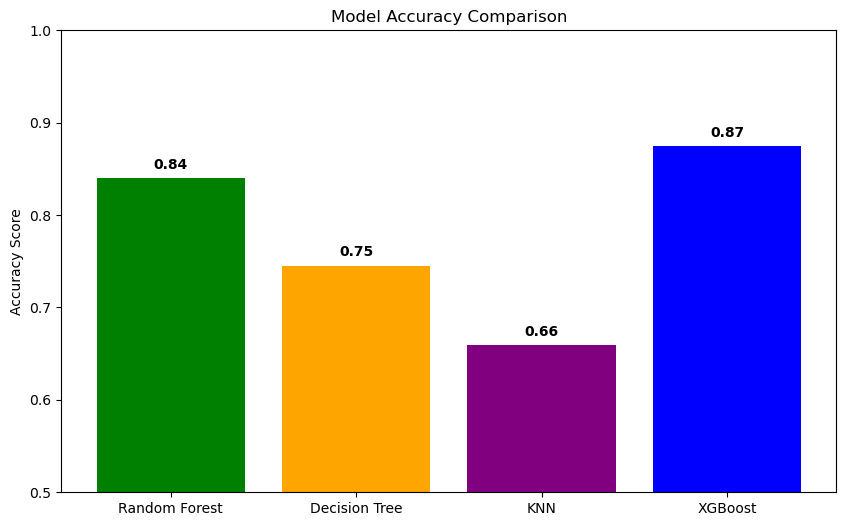

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from imblearn.over_sampling import SMOTE  # or SMOTETomek

# Step 1: Split original data first
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y_processed, test_size=0.3, random_state=42, stratify=y_processed
)

# Step 2: Apply SMOTE (or SMOTETomek) to training set only
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

# Step 3: Now evaluate models on X_test, y_test
X_resampled = X_train_bal
y_resampled = y_train_bal

# Define and compare models
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
import matplotlib.pyplot as plt

models = {
    'Random Forest': RandomForestClassifier(random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'KNN': KNeighborsClassifier(),
    'XGBoost': XGBClassifier(eval_metric='logloss', random_state=42)
}

accuracy_scores = {}

for name, model in models.items():
    model.fit(X_resampled, y_resampled)
    score = model.score(X_test, y_test)  # y_test must match X_test
    accuracy_scores[name] = score
    print(f"{name} Accuracy: {score:.4f}")

# Plot the results
plt.figure(figsize=(10, 6))
plt.bar(accuracy_scores.keys(), accuracy_scores.values(), color=['green', 'orange', 'purple', 'blue'])
plt.ylabel("Accuracy Score")
plt.ylim(0.5, 1.0)
plt.title("Model Accuracy Comparison")
for i, v in enumerate(accuracy_scores.values()):
    plt.text(i, v + 0.01, f"{v:.2f}", ha='center', fontweight='bold')
plt.show()


In [11]:
# ✅ 1. Imports
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from torch.utils.data import DataLoader, TensorDataset
from imblearn.over_sampling import SMOTE

# ✅ 2. Load your data (you must define `X` and `y`)
df = pd.read_csv("Loan_default.csv")

# Identify features (X) and target (y)
# Corrected: Drop 'LoanID' and target 'Default' from features
X = df.drop(['LoanID', 'Default'], axis=1)
y = df['Default'] # Corrected: Target column name is 'Default'

# Corrected: Apply Label Encoding to categorical features
# Identify categorical columns (object dtype)
categorical_cols = X.select_dtypes(include=['object']).columns

# Apply LabelEncoder to each categorical column
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])

# ✅ 3. Train/Test Split BEFORE Resampling
# Ensure stratify is used for imbalanced datasets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# ✅ 4. Apply SMOTE ONLY to training data
sm = SMOTE(random_state=42)
X_train_bal, y_train_bal = sm.fit_resample(X_train, y_train)

# ✅ 5. Feature Scaling (Standardization)
scaler = StandardScaler()
X_train_bal = scaler.fit_transform(X_train_bal)
X_test = scaler.transform(X_test)

# ✅ 6. Convert to PyTorch Tensors
X_train_tensor = torch.tensor(X_train_bal, dtype=torch.float32)
# .values is not needed if y_train_bal is already a numpy array from sm.fit_resample or a pandas Series
y_train_tensor = torch.tensor(y_train_bal, dtype=torch.float32).view(-1, 1) # Ensure target is 2D for BCEWithLogitsLoss

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
# Ensure target is 2D for BCEWithLogitsLoss
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

# ✅ 7. DataLoader for Training
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

# ✅ 8. Define Neural Network Model
class LoanNet(nn.Module):
    def __init__(self, input_dim):
        super(LoanNet, self).__init__()
        self.fc1 = nn.Linear(input_dim, 64)
        self.fc2 = nn.Linear(64, 32)
        self.output = nn.Linear(32, 1) # Output layer for binary classification

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        # Corrected: Removed sigmoid here to use nn.BCEWithLogitsLoss for numerical stability
        return self.output(x)

# ✅ 9. Initialize Model, Loss, Optimizer
input_dim = X_train_tensor.shape[1]
model = LoanNet(input_dim)
# Corrected: Using BCEWithLogitsLoss for numerical stability, combines sigmoid and BCELoss
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# ✅ 10. Training Loop
epochs = 10
model.train() # Set model to training mode
for epoch in range(epochs):
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        output = model(batch_X)
        loss = criterion(output, batch_y)
        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}")

# ✅ 11. Evaluation
model.eval() # Set model to evaluation mode
with torch.no_grad():
    predictions_logits = model(X_test_tensor)
    # Apply sigmoid to logits to get probabilities for thresholding
    probabilities = torch.sigmoid(predictions_logits)
    predicted_classes = (probabilities >= 0.5).int()

# ✅ 12. Final Accuracy and other metrics
print("✅ Predictions shape:", predicted_classes.shape)
print("✅ Ground truth shape:", y_test_tensor.shape)

# Convert tensors to numpy for sklearn metrics
predicted_classes_np = predicted_classes.cpu().numpy()
y_test_np = y_test_tensor.cpu().numpy()

# Calculate metrics
accuracy = accuracy_score(y_test_np, predicted_classes_np)
precision = precision_score(y_test_np, predicted_classes_np)
recall = recall_score(y_test_np, predicted_classes_np)
f1 = f1_score(y_test_np, predicted_classes_np)
conf_matrix = confusion_matrix(y_test_np, predicted_classes_np)

print(f"\n✅ Test Accuracy: {accuracy:.4f}")
print(f"✅ Test Precision: {precision:.4f}")
print(f"✅ Test Recall: {recall:.4f}")
print(f"✅ Test F1-Score: {f1:.4f}")
print("\n✅ Confusion Matrix:")
print(conf_matrix)

Epoch 1/10, Loss: 0.4123
Epoch 2/10, Loss: 0.3729
Epoch 3/10, Loss: 0.3045
Epoch 4/10, Loss: 0.6058
Epoch 5/10, Loss: 0.3240
Epoch 6/10, Loss: 0.3486
Epoch 7/10, Loss: 0.5421
Epoch 8/10, Loss: 0.1646
Epoch 9/10, Loss: 0.4021
Epoch 10/10, Loss: 0.3285
✅ Predictions shape: torch.Size([51070, 1])
✅ Ground truth shape: torch.Size([51070, 1])

✅ Test Accuracy: 0.7896
✅ Test Precision: 0.2338
✅ Test Recall: 0.3563
✅ Test F1-Score: 0.2823

✅ Confusion Matrix:
[[38214  6925]
 [ 3818  2113]]


In [12]:
print("X_test_tensor shape:", X_test_tensor.shape)
print("y_test_tensor shape:", y_test_tensor.shape)


X_test_tensor shape: torch.Size([51070, 16])
y_test_tensor shape: torch.Size([76605])


In [12]:
# ✅ 1. Imports (Same as before)
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from torch.utils.data import DataLoader, TensorDataset
from imblearn.over_sampling import SMOTE

# ✅ 2. Load your data
df = pd.read_csv("Loan_default.csv")

# Identify features (X) and target (y)
X = df.drop(['LoanID', 'Default'], axis=1)
y = df['Default']

# Apply Label Encoding to categorical features
categorical_cols = X.select_dtypes(include=['object']).columns
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])

# ✅ 3. Train/Test Split BEFORE Resampling
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# ✅ 4. Apply SMOTE ONLY to training data
sm = SMOTE(random_state=42)
X_train_bal, y_train_bal = sm.fit_resample(X_train, y_train)

# ✅ 5. Feature Scaling (Standardization)
scaler = StandardScaler()
X_train_bal = scaler.fit_transform(X_train_bal)
X_test = scaler.transform(X_test)

# ✅ 6. Convert to PyTorch Tensors
X_train_tensor = torch.tensor(X_train_bal, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_bal, dtype=torch.float32).view(-1, 1)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

# ✅ 7. DataLoader for Training
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

# ✅ 8. Define Convolutional Neural Network Model (1D CNN)
class LoanCNN(nn.Module):
    def __init__(self, input_features):
        super(LoanCNN, self).__init__()
        # input_features is the sequence_length for Conv1d when channels=1
        # Input: (batch_size, 1, input_features)

        self.conv1 = nn.Conv1d(in_channels=1, out_channels=32, kernel_size=3, padding=1)
        # Output of conv1: (batch_size, 32, input_features) - if padding=1 and stride=1, output sequence length is same as input
        self.pool1 = nn.MaxPool1d(kernel_size=2, stride=2)
        # Output of pool1: (batch_size, 32, input_features // 2)

        self.conv2 = nn.Conv1d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        # Output of conv2: (batch_size, 64, input_features // 2)
        self.pool2 = nn.MaxPool1d(kernel_size=2, stride=2)
        # Output of pool2: (batch_size, 64, input_features // 4)

        # Calculate the size of the flattened layer input
        # We need to pass a dummy tensor through the conv layers to get the output shape
        # This is a common way to dynamically calculate the input size for the first linear layer
        self._to_linear = None
        self._calculate_flat_features(input_features)

        self.fc1 = nn.Linear(self._to_linear, 128)
        self.fc2 = nn.Linear(128, 64)
        self.output = nn.Linear(64, 1)

    def _calculate_flat_features(self, input_features):
        # Create a dummy tensor to pass through the convolutional layers
        # Input shape for Conv1d is (batch_size, channels, sequence_length)
        x = torch.randn(1, 1, input_features)
        x = self.pool1(F.relu(self.conv1(x)))
        x = self.pool2(F.relu(self.conv2(x)))
        self._to_linear = x.numel() # Get total number of elements after flattening

    def forward(self, x):
        # Reshape input for Conv1d: (batch_size, channels=1, sequence_length=num_features)
        x = x.unsqueeze(1) # Adds a channel dimension (1, input_features) -> (1, 1, input_features)

        x = self.pool1(F.relu(self.conv1(x)))
        x = self.pool2(F.relu(self.conv2(x)))

        x = x.view(-1, self._to_linear) # Flatten the output of convolutional layers
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.output(x)

# ✅ 9. Initialize Model, Loss, Optimizer
input_dim = X_train_tensor.shape[1]
model = LoanCNN(input_features=input_dim) # Use LoanCNN instead of LoanNet
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# --- Optional: Move model and data to GPU if available ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
X_test_tensor = X_test_tensor.to(device)
y_test_tensor = y_test_tensor.to(device)
print(f"Using device: {device}")
# ---------------------------------------------------------

# ✅ 10. Training Loop (Same as before)
epochs = 10
model.train()
for epoch in range(epochs):
    for batch_X, batch_y in train_loader:
        # Move batch to device (CPU/GPU)
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)

        optimizer.zero_grad()
        output = model(batch_X)
        loss = criterion(output, batch_y)
        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}")

# ✅ 11. Evaluation (Same as before)
model.eval()
with torch.no_grad():
    predictions_logits = model(X_test_tensor)
    probabilities = torch.sigmoid(predictions_logits)
    predicted_classes = (probabilities >= 0.5).int()

# ✅ 12. Final Accuracy and other metrics (Same as before)
print("\n✅ Predictions shape:", predicted_classes.shape)
print("✅ Ground truth shape:", y_test_tensor.shape)

predicted_classes_np = predicted_classes.cpu().numpy()
y_test_np = y_test_tensor.cpu().numpy()

accuracy = accuracy_score(y_test_np, predicted_classes_np)
precision = precision_score(y_test_np, predicted_classes_np)
recall = recall_score(y_test_np, predicted_classes_np)
f1 = f1_score(y_test_np, predicted_classes_np)
conf_matrix = confusion_matrix(y_test_np, predicted_classes_np)

print(f"\n✅ Test Accuracy: {accuracy:.4f}")
print(f"✅ Test Precision: {precision:.4f}")
print(f"✅ Test Recall: {recall:.4f}")
print(f"✅ Test F1-Score: {f1:.4f}")
print("\n✅ Confusion Matrix:")
print(conf_matrix)

Using device: cpu
Epoch 1/10, Loss: 0.2927
Epoch 2/10, Loss: 0.4028
Epoch 3/10, Loss: 0.3324
Epoch 4/10, Loss: 0.3742
Epoch 5/10, Loss: 0.2920
Epoch 6/10, Loss: 0.1848
Epoch 7/10, Loss: 0.7164
Epoch 8/10, Loss: 0.4539
Epoch 9/10, Loss: 0.3027
Epoch 10/10, Loss: 0.3323

✅ Predictions shape: torch.Size([51070, 1])
✅ Ground truth shape: torch.Size([51070, 1])

✅ Test Accuracy: 0.8006
✅ Test Precision: 0.2277
✅ Test Recall: 0.2998
✅ Test F1-Score: 0.2588

✅ Confusion Matrix:
[[39108  6031]
 [ 4153  1778]]


In [52]:
# ✅ 1. Imports
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from torch.utils.data import DataLoader, TensorDataset
from imblearn.over_sampling import SMOTE

# ✅ 2. Load your data
df = pd.read_csv("Loan_default.csv")

# Identify features (X) and target (y)
# Drop 'LoanID' and the target 'Default' from features
X = df.drop(['LoanID', 'Default'], axis=1)
y = df['Default'] # Target column name is 'Default'

# Apply Label Encoding to categorical features
categorical_cols = X.select_dtypes(include=['object']).columns
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])

# ✅ 3. Train/Test Split BEFORE Resampling
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# ✅ 4. Apply SMOTE ONLY to training data
sm = SMOTE(random_state=42)
X_train_bal, y_train_bal = sm.fit_resample(X_train, y_train)

# ✅ 5. Feature Scaling (Standardization)
scaler = StandardScaler()
X_train_bal = scaler.fit_transform(X_train_bal)
X_test = scaler.transform(X_test)

# ✅ 6. Convert to PyTorch Tensors
X_train_tensor = torch.tensor(X_train_bal, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_bal, dtype=torch.float32).view(-1, 1)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

# ✅ 7. DataLoader for Training
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

# ✅ 8. Define Deep Neural Network (Feed-forward Network) Model
class LoanNet(nn.Module):
    def __init__(self, input_dim):
        super(LoanNet, self).__init__()
        self.fc1 = nn.Linear(input_dim, 64) # First hidden layer
        self.dropout1 = nn.Dropout(p=0.3) # Added Dropout layer
        self.fc2 = nn.Linear(64, 32) # Second hidden layer
        self.dropout2 = nn.Dropout(p=0.3) # Added Dropout layer
        self.output = nn.Linear(32, 1) # Output layer for binary classification

    def forward(self, x):
        x = F.relu(self.fc1(x)) # ReLU activation
        x = self.dropout1(x) # Apply Dropout
        x = F.relu(self.fc2(x)) # ReLU activation
        x = self.dropout2(x) # Apply Dropout
        return self.output(x) # Returns logits for BCEWithLogitsLoss

# ✅ 9. Initialize Model, Loss, Optimizer
input_dim = X_train_tensor.shape[1]
model = LoanNet(input_dim)
criterion = nn.BCEWithLogitsLoss() # Numerically stable loss for binary classification
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# --- Optional: Move model and data to GPU if available ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
X_test_tensor = X_test_tensor.to(device)
y_test_tensor = y_test_tensor.to(device)
print(f"Using device: {device}")
# ---------------------------------------------------------

# ✅ 10. Training Loop
epochs = 10
model.train()
for epoch in range(epochs):
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)

        optimizer.zero_grad()
        output = model(batch_X)
        loss = criterion(output, batch_y)
        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}")

# ✅ 11. Evaluation
model.eval()
with torch.no_grad():
    predictions_logits = model(X_test_tensor)
    probabilities = torch.sigmoid(predictions_logits)
    predicted_classes = (probabilities >= 0.5).int()

# ✅ 12. Final Accuracy and other metrics
print("\n✅ Predictions shape:", predicted_classes.shape)
print("✅ Ground truth shape:", y_test_tensor.shape)

predicted_classes_np = predicted_classes.cpu().numpy()
y_test_np = y_test_tensor.cpu().numpy()

accuracy = accuracy_score(y_test_np, predicted_classes_np)
precision = precision_score(y_test_np, predicted_classes_np)
recall = recall_score(y_test_np, predicted_classes_np)
f1 = f1_score(y_test_np, predicted_classes_np)
conf_matrix = confusion_matrix(y_test_np, predicted_classes_np)

print(f"\n✅ Test Accuracy: {accuracy:.4f}")
print(f"✅ Test Precision: {precision:.4f}")
print(f"✅ Test Recall: {recall:.4f}")
print(f"✅ Test F1-Score: {f1:.4f}")
print("\n✅ Confusion Matrix:")
print(conf_matrix)

Using device: cpu
Epoch 1/10, Loss: 0.6432
Epoch 2/10, Loss: 0.2833
Epoch 3/10, Loss: 0.5168
Epoch 4/10, Loss: 0.2314
Epoch 5/10, Loss: 0.3880
Epoch 6/10, Loss: 0.4651
Epoch 7/10, Loss: 0.3881
Epoch 8/10, Loss: 0.2921
Epoch 9/10, Loss: 0.5614
Epoch 10/10, Loss: 0.3281

✅ Predictions shape: torch.Size([51070, 1])
✅ Ground truth shape: torch.Size([51070, 1])

✅ Test Accuracy: 0.7920
✅ Test Precision: 0.2393
✅ Test Recall: 0.3628
✅ Test F1-Score: 0.2884

✅ Confusion Matrix:
[[38297  6842]
 [ 3779  2152]]


In [13]:
import joblib
# ... (your XGBoost training code) ...

# After xgb.fit(x_train, y_train):
joblib.dump(xgb, 'xgboost_loan_model.pkl')
joblib.dump(scaler, 'scaler.pkl') # Make sure you save your fitted scaler
joblib.dump(label_encoders, 'label_encoders.pkl') # Make sure you save your fitted label_encoders

['label_encoders.pkl']

In [21]:
import os
print("Current Working Directory:", os.getcwd())


Current Working Directory: C:\Users\vshya\OneDrive\Desktop\Projects\Loan


In [22]:
import os
print("Files in Current Directory:")
for f in os.listdir(os.getcwd()):
    print(f)

Files in Current Directory:
.ipynb_checkpoints
app.py
label_encoders.pkl
Loan_default.csv
Loan_Prediction.ipynb
scaler.pkl
xgboost_loan_model.pkl


In [71]:
import streamlit as st
import pandas as pd
import numpy as np
import joblib # Used for loading saved Python objects

# --- 1. Load Pre-trained Model and Preprocessors ---
try:
    model = joblib.load('xgboost_loan_model.pkl')
    scaler = joblib.load('scaler.pkl')
    label_encoders = joblib.load('label_encoders.pkl')
    st.sidebar.success("Model and preprocessors loaded successfully!")

    # --- DEBUG LINE (for initial scaler check) ---
    if hasattr(scaler, 'n_features_in_'):
        st.sidebar.write(f"DEBUG (Scaler Load): Loaded StandardScaler expects {scaler.n_features_in_} features.")
    else:
        st.sidebar.write("DEBUG (Scaler Load): Loaded StandardScaler has no n_features_in_ attribute.")
    # --- END DEBUG LINE ---

except FileNotFoundError:
    st.error("Error: Model or preprocessor files not found. Please ensure 'xgboost_loan_model.pkl', 'scaler.pkl', and 'label_encoders.pkl' are in the same directory as app.py, and that you've run the model preparation code first.")
    st.stop()

# --- 2. Define Feature Names and Their Types ---
# This list MUST be in the same order as the features were during model training.
feature_names = [
    'Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed',
    'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio',
    'Education', 'EmploymentType', 'MaritalStatus', 'HasMortgage',
    'HasDependents', 'LoanPurpose', 'HasCoSigner'
]

numerical_features = [
    'Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed',
    'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio'
]

categorical_features_options = {
    'Education': ['High School', 'Bachelor\'s', 'Master\'s', 'PhD'],
    'EmploymentType': ['Full-time', 'Part-time', 'Self-employed', 'Unemployed'],
    'MaritalStatus': ['Single', 'Married', 'Divorced'],
    'HasMortgage': ['No', 'Yes'],
    'HasDependents': ['No', 'Yes'],
    'LoanPurpose': ['Business', 'Education', 'Home', 'Other', 'Auto', 'Debt Consolidation'],
    'HasCoSigner': ['No', 'Yes']
}

# --- 3. Streamlit App Interface ---
st.set_page_config(page_title="Loan Eligibility Predictor", layout="centered")

st.title("💰 Loan Eligibility Predictor")
st.write("Enter the applicant's details below to find out their loan eligibility.")

# --- Custom Threshold Configuration ---
st.sidebar.header("Prediction Settings")
# Allow user to adjust the threshold for classification
default_risk_threshold = st.sidebar.slider(
    "Set Default Risk Threshold (%)",
    min_value=0, max_value=100, value=30, step=1,
    help="Probability of Default (%) above which the loan is considered 'Not Eligible'."
) / 100.0 # Convert to a decimal

st.sidebar.info(f"Loans with a default probability of {default_risk_threshold:.0%} or higher will be classified as 'Not Eligible'.")
# --- End Custom Threshold Configuration ---


# Create input fields within a form
with st.form("loan_form"):
    st.header("Applicant Information")

    input_data = {} # Dictionary to store user inputs

    # Numerical Inputs (with appropriate min/max values and steps)
    st.subheader("Numerical Details")
    col1, col2 = st.columns(2)
    with col1:
        input_data['Age'] = st.slider("Age", min_value=18, max_value=80, value=35)
        input_data['Income'] = st.number_input("Annual Income ($)", min_value=0, value=6000000, step=1000) # Default to 6M
        input_data['LoanAmount'] = st.number_input("Loan Amount Requested ($)", min_value=0, value=150000, step=5000) # Default to 150K
        input_data['CreditScore'] = st.number_input("Credit Score (300-850)", min_value=300, max_value=850, value=650, step=1)
        input_data['MonthsEmployed'] = st.number_input("Months Employed", min_value=0, value=12, step=1) # Default to 12
    with col2:
        input_data['NumCreditLines'] = st.number_input("Number of Credit Lines", min_value=0, max_value=10, value=2, step=1)
        input_data['InterestRate'] = st.number_input("Interest Rate (%)", min_value=0.0, max_value=25.0, value=7.5, step=0.1)
        input_data['LoanTerm'] = st.number_input("Loan Term (Months)", min_value=12, max_value=120, value=36, step=6)
        input_data['DTIRatio'] = st.number_input("Debt-to-Income Ratio (0.0-1.0)", min_value=0.0, max_value=1.0, value=0.4, step=0.01)

    # Categorical Inputs (using selectbox)
    st.subheader("Other Details")
    col3, col4 = st.columns(2)
    with col3:
        input_data['Education'] = st.selectbox("Education Level", categorical_features_options['Education'])
        input_data['EmploymentType'] = st.selectbox("Employment Type", categorical_features_options['EmploymentType'], index=categorical_features_options['EmploymentType'].index('Full-time')) # Default to Full-time
    with col4:
        input_data['MaritalStatus'] = st.selectbox("Marital Status", categorical_features_options['MaritalStatus'], index=categorical_features_options['MaritalStatus'].index('Married')) # Default to Married
        input_data['HasMortgage'] = st.selectbox("Has a Mortgage?", categorical_features_options['HasMortgage'])
        input_data['HasDependents'] = st.selectbox("Has Dependents?", categorical_features_options['HasDependents'])
        input_data['LoanPurpose'] = st.selectbox("Loan Purpose", categorical_features_options['LoanPurpose'])
        input_data['HasCoSigner'] = st.selectbox("Has a Co-Signer?", categorical_features_options['HasCoSigner'])

    submitted = st.form_submit_button("Predict Eligibility")

# --- 4. Prediction Logic ---
if submitted:
    # 1. Create a DataFrame from the input_data, ensuring ALL columns are present and in the correct order.
    input_values_ordered = [input_data[feat] for feat in feature_names]
    input_df_for_processing = pd.DataFrame([input_values_ordered], columns=feature_names)

    # 2. Apply Label Encoding to categorical features in this DataFrame.
    for col in categorical_features_options.keys():
        if col in input_df_for_processing.columns:
            le = label_encoders[col]
            try:
                # Transform needs a list-like input for a single value
                input_df_for_processing[col] = le.transform([input_df_for_processing[col].iloc[0]])[0]
            except ValueError:
                st.error(f"Error encoding '{col}': The selected category '{input_df_for_processing[col].iloc[0]}' was not seen during model training. Please ensure valid options are selected.")
                st.stop()

    # --- NEW: Apply Log Transformation to highly skewed numerical features ---
    # It's common practice to apply log transformation (np.log1p for 1 + value to handle 0s)
    # to highly skewed features like Income and LoanAmount before scaling.
    # This helps the scaler and model handle large, outlier values better by compressing their range.
    # IMPORTANT: Ideally, your model should also have been trained on log-transformed data for these features.
    input_df_for_processing['Income'] = np.log1p(input_df_for_processing['Income'])
    input_df_for_processing['LoanAmount'] = np.log1p(input_df_for_processing['LoanAmount'])

    # --- DEBUG LINE (for input to scaler) ---
    print(f"DEBUG (Scaler Input Data - All Features, after log1p): Columns: {input_df_for_processing.columns.tolist()}")
    print(f"DEBUG (Scaler Input Data - All Features, after log1p): Shape: {input_df_for_processing.shape}")
    # --- END DEBUG LINE ---

    # 3. Scale Features.
    # This aligns with a scaler that was (incorrectly) fitted on all features to resolve previous ValueErrors.
    scaled_data_array = scaler.transform(input_df_for_processing)

    # Convert the scaled array back to a DataFrame to maintain column names.
    final_input_for_model = pd.DataFrame(scaled_data_array, columns=feature_names)

    # 4. Make prediction using the loaded XGBoost model.
    prediction_proba = model.predict_proba(final_input_for_model)[:, 1][0]
    
    # 5. Apply the custom threshold for final classification
    prediction_class = 1 if prediction_proba >= default_risk_threshold else 0

    st.subheader("Prediction Result:")
    if prediction_class == 0:
        st.success(f"**Eligible for Loan!**")
        st.write(f"The model predicts a default probability of: **{prediction_proba:.2%}**.")
        st.balloons()
    else:
        st.error(f"**Not Eligible for Loan.**")
        st.write(f"The model predicts a default probability of: **{prediction_proba:.2%}**.")

2025-07-20 12:56:53.859 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-07-20 12:56:53.860 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-07-20 12:56:53.861 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-07-20 12:56:53.862 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-07-20 12:56:53.863 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-07-20 12:56:53.864 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-07-20 12:56:53.867 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-07-20 12:56:53.868 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

2025-07-20 12:56:54.000 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-07-20 12:56:54.001 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-07-20 12:56:54.002 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-07-20 12:56:54.003 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-07-20 12:56:54.004 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-07-20 12:56:54.005 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-07-20 12:56:54.007 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-07-20 12:56:54.008 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

2025-07-20 12:56:54.091 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-07-20 12:56:54.092 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-07-20 12:56:54.093 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-07-20 12:56:54.095 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-07-20 12:56:54.096 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-07-20 12:56:54.097 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-07-20 12:56:54.098 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-07-20 12:56:54.099 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

In [34]:
!type app.py

import streamlit as st
import pandas as pd
import numpy as np
import joblib # Used for loading saved Python objects

# --- 1. Load Pre-trained Model and Preprocessors ---
try:
    model = joblib.load('xgboost_loan_model.pkl')
    scaler = joblib.load('scaler.pkl')
    label_encoders = joblib.load('label_encoders.pkl')
    st.sidebar.success("Model and preprocessors loaded successfully!")

    # --- DEBUG LINE (for initial scaler check) ---
    if hasattr(scaler, 'n_features_in_'):
        st.sidebar.write(f"DEBUG (Scaler Load): Loaded StandardScaler expects {scaler.n_features_in_} features.")
    else:
        st.sidebar.write("DEBUG (Scaler Load): Loaded StandardScaler has no n_features_in_ attribute.")
    # --- END DEBUG LINE ---

except FileNotFoundError:
    st.error("Error: Model or preprocessor files not found. Please ensure 'xgboost_loan_model.pkl', 'scaler.pkl', and 'label_encoders.pkl' are in the same directory as app.py, and that you've run the model preparation code first."

In [55]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
import joblib

# Step 1: Load dataset
df = pd.read_csv("Loan_default.csv")
df.columns = df.columns.str.strip() # Remove extra spaces

# Step 2: Define columns (now including all 16 features to match app.py)
target_col = 'Default' # Corrected target column name based on previous error
categorical_cols = ['Education', 'EmploymentType', 'MaritalStatus', 'LoanPurpose',
                    'HasMortgage', 'HasDependents', 'HasCoSigner']
# Corrected numerical_cols to match actual CSV column names
numerical_cols = ['Age', 'Income', 'LoanAmount', 'CreditScore',
                  'MonthsEmployed', 'NumCreditLines', 'InterestRate',
                  'LoanTerm', 'DTIRatio']

# This list MUST be in the same order as the feature_names in app.py
feature_names_for_model = [
    'Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed',
    'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio',
    'Education', 'EmploymentType', 'MaritalStatus', 'HasMortgage',
    'HasDependents', 'LoanPurpose', 'HasCoSigner'
]


# Step 3: Drop rows with missing target
df = df.dropna(subset=[target_col])

# Step 4: Encode categorical variables
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = df[col].astype(str)
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

# Step 5: Scale numerical variables
scaler = StandardScaler()
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

# Step 6: Train-test split
# Ensure X contains all 16 features in the correct order for the model
X = df[feature_names_for_model]
y = df[target_col].astype(int)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ✅ Step 7: Train XGBoost model (with new parameters for balanced feature preference)
model = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    colsample_bytree=0.8, # Added: Subsample columns for each tree
    gamma=0.1,            # Added: Minimum loss reduction required to make a split
    random_state=42       # Keep for reproducibility
)
model.fit(X_train, y_train)

# Step 8: Evaluate
y_pred = model.predict(X_test)
print("✅ Test Accuracy (XGBoost):", accuracy_score(y_test, y_pred))

# Step 9: Save model and encoders
joblib.dump(model, "xgboost_loan_model.pkl")
joblib.dump(label_encoders, "label_encoders.pkl")
joblib.dump(scaler, "scaler.pkl")

print("\n--- Model Preparation Complete ---")
print("All necessary files saved successfully: 'xgboost_loan_model.pkl', 'scaler.pkl', 'label_encoders.pkl'")
print("You can now proceed to run your Streamlit app.")


# Step 10: Sample input for prediction (now with 16 features for demonstration)
input_data = {
    'Age': 30,
    'Income': 60000, # Corrected from AnnualIncome
    'LoanAmount': 20000,
    'CreditScore': 700,
    'MonthsEmployed': 24,
    'NumCreditLines': 3,
    'InterestRate': 7.5,
    'LoanTerm': 36,
    'DTIRatio': 0.25, # Corrected from DebtToIncomeRatio
    'Education': 'Bachelor\'s',
    'EmploymentType': 'Full-time',
    'MaritalStatus': 'Single',
    'LoanPurpose': 'Home',
    'HasMortgage': 'No',
    'HasDependents': 'Yes',
    'HasCoSigner': 'No'
}

input_df = pd.DataFrame([input_data])

# Ensure input_df has all 16 features in the correct order before processing
input_df = input_df[feature_names_for_model]


# Encode categoricals
for col in categorical_cols:
    if col in input_df.columns:
        input_df[col] = label_encoders[col].transform([input_df[col].iloc[0]])[0]

# Scale numericals
input_df[numerical_cols] = scaler.transform(input_df[numerical_cols])

# Predict
prediction = model.predict(input_df)
print("\n🔮 Prediction (0 = No Default, 1 = Default):", prediction[0])

C:\Users\vshya\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [12:08:02] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


✅ Test Accuracy (XGBoost): 0.886724104170746

--- Model Preparation Complete ---
All necessary files saved successfully: 'xgboost_loan_model.pkl', 'scaler.pkl', 'label_encoders.pkl'
You can now proceed to run your Streamlit app.

🔮 Prediction (0 = No Default, 1 = Default): 0


In [38]:
from sklearn.metrics import accuracy_score

# ✅ Predict using XGBoost model
xgb_preds = xgb_model.predict(X_test)

# If it's a classification problem and predictions are probabilities:
# xgb_preds = (xgb_model.predict_proba(X_test)[:, 1] >= 0.5).astype(int)

# ✅ Compare with true labels
accuracy = accuracy_score(y_test, xgb_preds)
print(f"\n✅ Final Test Accuracy (XGBoost): {accuracy:.4f}")



✅ Final Test Accuracy (XGBoost): 0.8730


In [70]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from imblearn.over_sampling import SMOTE
import joblib # Used for saving/loading Python objects

print("--- Starting Model Preparation ---")

# --- 1. Load Data ---
print("Loading data...")
df = pd.read_csv("Loan_default.csv")

# --- 2. Separate Features (X) and Target (y) ---
X = df.drop(['LoanID', 'Default'], axis=1)
y = df['Default']
print(f"Original data shape: {df.shape}")

# --- NEW: Apply Log Transformation to highly skewed numerical features in X ---
# Apply np.log1p (log(1+x)) to Income and LoanAmount to reduce skewness and handle outliers.
# This is crucial for Standard Scaler to work effectively on wide-ranging data.
print("Applying log1p transformation to 'Income' and 'LoanAmount'...")
X['Income'] = np.log1p(X['Income'])
X['LoanAmount'] = np.log1p(X['LoanAmount'])
# --- END NEW ---

# --- 3. Preprocessing: Label Encoding for Categorical Features ---
print("Applying Label Encoding to categorical features...")
label_encoders = {}
categorical_cols = X.select_dtypes(include=['object']).columns

for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le # Store the fitted encoder

print(f"Categorical columns encoded: {list(categorical_cols)}")

# --- 4. Train/Test Split BEFORE Resampling ---
print("Splitting data into training and testing sets (80/20)...")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# --- 5. Handle Class Imbalance using SMOTE on Training Data ONLY ---
print("Applying SMOTE to balance the training data...")
sm = SMOTE(random_state=42)
X_train_bal, y_train_bal = sm.fit_resample(X_train, y_train)
print(f"X_train_balanced shape: {X_train_bal.shape}")

# --- 6. Feature Scaling (Standardization) ---
print("Applying StandardScaler to numerical features...")
scaler = StandardScaler()
numerical_features = X.select_dtypes(include=np.number).columns
X_train_bal[numerical_features] = scaler.fit_transform(X_train_bal[numerical_features])
# Transform the test set using the *fitted* scaler from the training data
X_test[numerical_features] = scaler.transform(X_test[numerical_features])
print("Features scaled.")

# --- 7. Train XGBoost Classifier ---
print("Training XGBoost Classifier (this might take a while)...")
xgb_model = xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train_bal, y_train_bal)
print("XGBoost model trained.")

# --- 8. Save the Trained Model, Scaler, and Label Encoders ---
print("Saving model, scaler, and label encoders...")
joblib.dump(xgb_model, 'xgboost_loan_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(label_encoders, 'label_encoders.pkl')
print("All necessary files saved successfully: 'xgboost_loan_model.pkl', 'scaler.pkl', 'label_encoders.pkl'")

print("\n--- Model Preparation Complete ---")
print("You can now proceed to the next cell to create and run the Streamlit app.")

--- Starting Model Preparation ---
Loading data...
Original data shape: (255347, 18)
Applying log1p transformation to 'Income' and 'LoanAmount'...
Applying Label Encoding to categorical features...
Categorical columns encoded: ['Education', 'EmploymentType', 'MaritalStatus', 'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner']
Splitting data into training and testing sets (80/20)...
Applying SMOTE to balance the training data...
X_train_balanced shape: (361110, 16)
Applying StandardScaler to numerical features...
Features scaled.
Training XGBoost Classifier (this might take a while)...


C:\Users\vshya\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [12:56:24] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost model trained.
Saving model, scaler, and label encoders...
All necessary files saved successfully: 'xgboost_loan_model.pkl', 'scaler.pkl', 'label_encoders.pkl'

--- Model Preparation Complete ---
You can now proceed to the next cell to create and run the Streamlit app.
